In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from scipy.interpolate import make_interp_spline

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

## 预处理

- 全球陆地边界矢量：https://gitcode.com/open-source-toolkit/ef713
- 全球国家行政区划：https://www.naturalearthdata.com/downloads/110m-cultural-vectors
- 全球历史洪涝事件矢量：https://zenodo.org/records/18647054

In [2]:
gdf = gpd.read_parquet("data\groundsource_2026.parquet")
world = gpd.read_file("data/全球国家区划矢量_去除南极洲.shp")[["NAME_ZH","NAME_EN","REGION_UN","CONTINENT","geometry"]]
land = gpd.read_file("data/全球陆地矢量_去除南极洲.shp")

In [3]:
gdf

,uuid,area_km2,geometry,start_date,end_date
0,5acc1866dd6644dfa572f02ae3d54aa4,91.678015,"MULTIPOLYGON (((8.64252 53.60898, 8.65179 53.6...",2000-01-01,2000-01-01
1,f80fccbefb1346a9b568907086e65226,609.968365,"MULTIPOLYGON (((-0.01457 51.65825, -0.00151 51...",2000-01-01,2000-01-01
2,d5c49c9e2c2045bfbfd6e3b3865efc3f,0.099688,"POLYGON ((-58.43034 -34.61363, -58.42461 -34.6...",2000-01-24,2000-01-24
3,ce7f01a29de040b39e138f198fc39d86,0.548906,"POLYGON ((23.44227 47.63646, 23.43369 47.6408,...",2000-01-30,2000-01-30
4,eb047dfea9ed406485010853226e0170,0.236562,"POLYGON ((-57.54008 -38.00748, -57.5575 -38.02...",2000-01-30,2000-01-30
...,...,...,...,...,...
2752385,8b32b1e01f7242ec8179f909a7d3d8bb,120.344373,"POLYGON ((-65.4828 -24.8816, -65.50216 -24.872...",2026-02-01,2026-02-01
2752386,868680c140af4947b99a68e6c1780092,355.447306,"POLYGON ((100.00405 -0.13621, 100.01529 -0.097...",2026-02-02,2026-02-02
2752387,58ecef64037d4924b8d9ab9d996fa329,159.382864,"POLYGON ((100.39491 -0.9428, 100.43242 -0.9168...",2026-02-02,2026-02-02
2752388,10c8bb300ac64d6184d8f2e2b124a784,24.828721,"POLYGON ((100.53131 -0.84448, 100.58269 -0.834...",2026-02-02,2026-02-02


In [4]:
world.head(2)

,NAME_ZH,NAME_EN,REGION_UN,CONTINENT,geometry
0,斐济,Fiji,Oceania,Oceania,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,坦桑尼亚,Tanzania,Africa,Africa,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."


In [5]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [6]:
world.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

- 提取为点

In [7]:
gdf1 = gdf.copy()
gdf1.geometry = gdf.geometry.representative_point()
gdf1 = gdf1[gdf1.geometry.notna()].copy()
gdf1

,uuid,area_km2,geometry,start_date,end_date
0,5acc1866dd6644dfa572f02ae3d54aa4,91.678015,POINT (8.59573 53.54306),2000-01-01,2000-01-01
1,f80fccbefb1346a9b568907086e65226,609.968365,POINT (-0.1164 51.536),2000-01-01,2000-01-01
2,d5c49c9e2c2045bfbfd6e3b3865efc3f,0.099688,POINT (-58.42593 -34.61225),2000-01-24,2000-01-24
3,ce7f01a29de040b39e138f198fc39d86,0.548906,POINT (23.4412 47.63863),2000-01-30,2000-01-30
4,eb047dfea9ed406485010853226e0170,0.236562,POINT (-57.54935 -38.0183),2000-01-30,2000-01-30
...,...,...,...,...,...
2752385,8b32b1e01f7242ec8179f909a7d3d8bb,120.344373,POINT (-65.42175 -24.79735),2026-02-01,2026-02-01
2752386,868680c140af4947b99a68e6c1780092,355.447306,POINT (100.20195 -0.16555),2026-02-02,2026-02-02
2752387,58ecef64037d4924b8d9ab9d996fa329,159.382864,POINT (100.50115 -0.86893),2026-02-02,2026-02-02
2752388,10c8bb300ac64d6184d8f2e2b124a784,24.828721,POINT (100.56458 -0.86664),2026-02-02,2026-02-02


In [8]:
world.sindex

# 空间连接
result = (
    gpd
    .sjoin(
        gdf1, 
        world, 
        how='left',
        predicate='within',
        lsuffix='left',
        rsuffix='right'
    )
    .dropna()
    .reset_index(drop=True)
)

In [9]:
result

,uuid,area_km2,geometry,start_date,end_date,index_right,NAME_ZH,NAME_EN,REGION_UN,CONTINENT
0,5acc1866dd6644dfa572f02ae3d54aa4,91.678015,POINT (8.59573 53.54306),2000-01-01,2000-01-01,121.0,德国,Germany,Europe,Europe
1,f80fccbefb1346a9b568907086e65226,609.968365,POINT (-0.1164 51.536),2000-01-01,2000-01-01,142.0,英国,United Kingdom,Europe,Europe
2,d5c49c9e2c2045bfbfd6e3b3865efc3f,0.099688,POINT (-58.42593 -34.61225),2000-01-24,2000-01-24,9.0,阿根廷,Argentina,Americas,South America
3,ce7f01a29de040b39e138f198fc39d86,0.548906,POINT (23.4412 47.63863),2000-01-30,2000-01-30,117.0,罗马尼亚,Romania,Europe,Europe
4,5f9e061913034a54a1eab44a418ddec4,40.239854,POINT (23.596 47.66912),2000-01-30,2000-01-30,117.0,罗马尼亚,Romania,Europe,Europe
...,...,...,...,...,...,...,...,...,...,...
2521683,8b32b1e01f7242ec8179f909a7d3d8bb,120.344373,POINT (-65.42175 -24.79735),2026-02-01,2026-02-01,9.0,阿根廷,Argentina,Americas,South America
2521684,868680c140af4947b99a68e6c1780092,355.447306,POINT (100.20195 -0.16555),2026-02-02,2026-02-02,8.0,印度尼西亚,Indonesia,Asia,Asia
2521685,58ecef64037d4924b8d9ab9d996fa329,159.382864,POINT (100.50115 -0.86893),2026-02-02,2026-02-02,8.0,印度尼西亚,Indonesia,Asia,Asia
2521686,10c8bb300ac64d6184d8f2e2b124a784,24.828721,POINT (100.56458 -0.86664),2026-02-02,2026-02-02,8.0,印度尼西亚,Indonesia,Asia,Asia


- 1°聚合

In [10]:
result['lon'] = result['geometry'].x
result['lat'] = result['geometry'].y

In [11]:
result['lon_grid'] = np.floor(result['lon']).astype(int)
result['lat_grid'] = np.floor(result['lat']).astype(int)

In [12]:
agg_1deg = result.groupby(['lon_grid', 'lat_grid']).agg(
    记录数=('uuid', 'count'),
    总面积_km2=('area_km2', 'sum'),
    平均面积_km2=('area_km2', 'mean'),
    国家列表=('NAME_ZH', lambda x: '、'.join(x.unique())),
    大洲=('CONTINENT', 'first')
).reset_index()

# 创建网格中心
agg_1deg['geometry'] = agg_1deg.apply(
    lambda row: Point(row['lon_grid'] + 0.5, row['lat_grid'] + 0.5), 
    axis=1
)

agg_1deg_gdf = gpd.GeoDataFrame(agg_1deg, geometry='geometry', crs=result.crs)

- 连接到世界地图

In [13]:
world

,NAME_ZH,NAME_EN,REGION_UN,CONTINENT,geometry
0,斐济,Fiji,Oceania,Oceania,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,坦桑尼亚,Tanzania,Africa,Africa,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,西撒哈拉,Western Sahara,Africa,Africa,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,加拿大,Canada,Americas,North America,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,美国,United States of America,Americas,North America,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
...,...,...,...,...,...
170,塞尔维亚,Serbia,Europe,Europe,"POLYGON ((18.82982 45.90887, 18.82984 45.90888..."
171,黑山,Montenegro,Europe,Europe,"POLYGON ((20.0707 42.58863, 19.80161 42.50009,..."
172,科索沃,Kosovo,Europe,Europe,"POLYGON ((20.59025 41.85541, 20.52295 42.21787..."
173,特立尼达和多巴哥,Trinidad and Tobago,Americas,North America,"POLYGON ((-61.68 10.76, -61.105 10.89, -60.895..."


In [14]:
result

,uuid,area_km2,geometry,start_date,end_date,index_right,NAME_ZH,NAME_EN,REGION_UN,CONTINENT,lon,lat,lon_grid,lat_grid
0,5acc1866dd6644dfa572f02ae3d54aa4,91.678015,POINT (8.59573 53.54306),2000-01-01,2000-01-01,121.0,德国,Germany,Europe,Europe,8.595727,53.543064,8,53
1,f80fccbefb1346a9b568907086e65226,609.968365,POINT (-0.1164 51.536),2000-01-01,2000-01-01,142.0,英国,United Kingdom,Europe,Europe,-0.116397,51.536003,-1,51
2,d5c49c9e2c2045bfbfd6e3b3865efc3f,0.099688,POINT (-58.42593 -34.61225),2000-01-24,2000-01-24,9.0,阿根廷,Argentina,Americas,South America,-58.425932,-34.612248,-59,-35
3,ce7f01a29de040b39e138f198fc39d86,0.548906,POINT (23.4412 47.63863),2000-01-30,2000-01-30,117.0,罗马尼亚,Romania,Europe,Europe,23.441204,47.638632,23,47
4,5f9e061913034a54a1eab44a418ddec4,40.239854,POINT (23.596 47.66912),2000-01-30,2000-01-30,117.0,罗马尼亚,Romania,Europe,Europe,23.596005,47.669116,23,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2521683,8b32b1e01f7242ec8179f909a7d3d8bb,120.344373,POINT (-65.42175 -24.79735),2026-02-01,2026-02-01,9.0,阿根廷,Argentina,Americas,South America,-65.421751,-24.797346,-66,-25
2521684,868680c140af4947b99a68e6c1780092,355.447306,POINT (100.20195 -0.16555),2026-02-02,2026-02-02,8.0,印度尼西亚,Indonesia,Asia,Asia,100.201950,-0.165550,100,-1
2521685,58ecef64037d4924b8d9ab9d996fa329,159.382864,POINT (100.50115 -0.86893),2026-02-02,2026-02-02,8.0,印度尼西亚,Indonesia,Asia,Asia,100.501150,-0.868927,100,-1
2521686,10c8bb300ac64d6184d8f2e2b124a784,24.828721,POINT (100.56458 -0.86664),2026-02-02,2026-02-02,8.0,印度尼西亚,Indonesia,Asia,Asia,100.564583,-0.866638,100,-1


In [15]:
world1 = world.merge(result.groupby("NAME_ZH").size().reset_index(name='记录数'), how='left', on='NAME_ZH')
world1['记录数'] = world1['记录数'].fillna(0)
world1.head(2)

,NAME_ZH,NAME_EN,REGION_UN,CONTINENT,geometry,记录数
0,斐济,Fiji,Oceania,Oceania,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",1353.0
1,坦桑尼亚,Tanzania,Africa,Africa,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",942.0


In [16]:
world1["记录数"]

0        1353.0
1         942.0
2           6.0
3       21288.0
4      228998.0
         ...   
170     10623.0
171      1026.0
172       675.0
173      3020.0
174       907.0
Name: 记录数, Length: 175, dtype: float64

## 制图

### 地图

In [17]:
world1 = world1.to_crs('ESRI:54030')
land = land.to_crs('ESRI:54030')
agg_1deg_gdf = agg_1deg_gdf.to_crs('ESRI:54030')

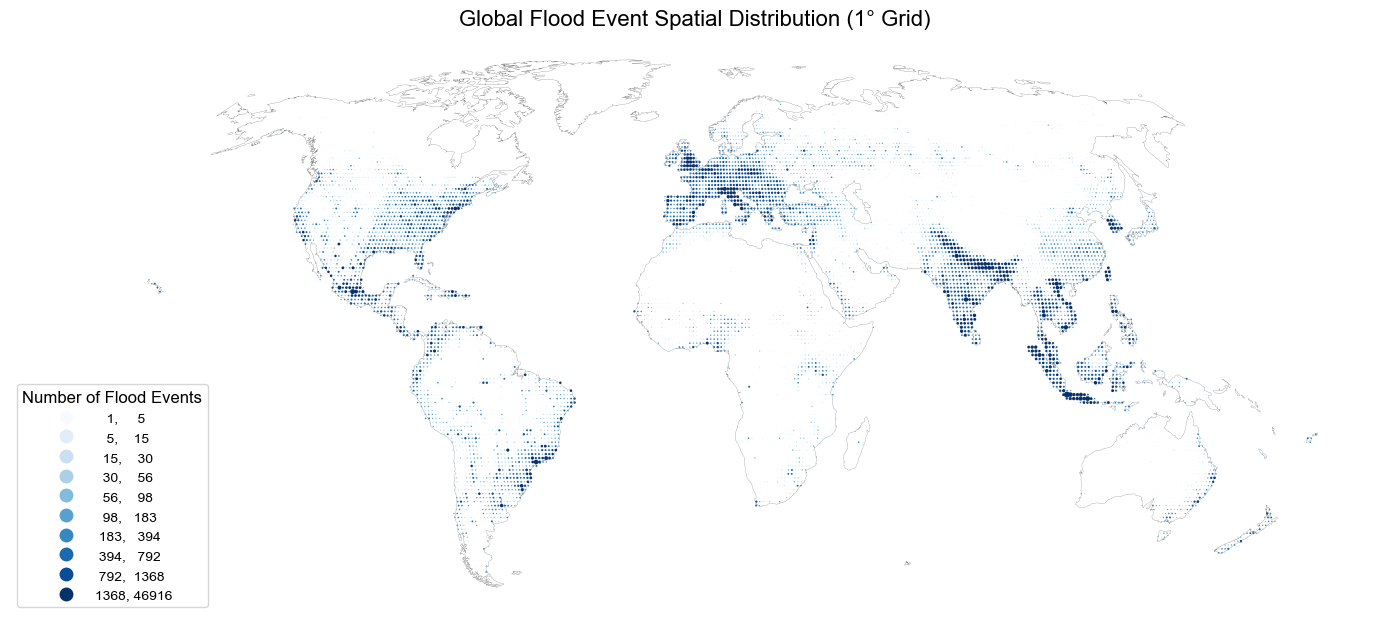

In [18]:
# 'boxplot', 'equalinterval', 'fisherjenks', 'fisherjenkssampled', 'headtailbreaks', 'jenkscaspall', 
# 'jenkscaspallforced', 'jenkscaspallsampled', 'maxp', 'maximumbreaks', 'naturalbreaks', 'quantiles', 
# 'percentiles', 'prettybreaks', 'stdmean', 'userdefined'
fig, ax = plt.subplots(figsize=(14, 12))

agg_1deg_gdf.plot(
    ax=ax,
    column='记录数',
    cmap='Blues',
    scheme='jenkscaspallsampled',
    k=10,
    legend=True,
    markersize=np.sqrt(agg_1deg_gdf['记录数']) / 12,
    linewidth=0,
    legend_kwds={
        'loc': 'lower left', 
        'fontsize': 10, 
        'fmt': '{:.0f}',
        'title_fontsize': 12, 
        'title': 'Number of Flood Events'
    },
    zorder=2
)
land.boundary.plot(
    ax=ax,
    lw=0.1,
    ec="black",
    zorder=1
)
ax.axis('off')
ax.set_title('Global Flood Event Spatial Distribution (1° Grid)', fontsize=16) # 使用en标题

plt.tight_layout()
plt.savefig('global_flood.png', dpi=1000, bbox_inches='tight')
plt.show()

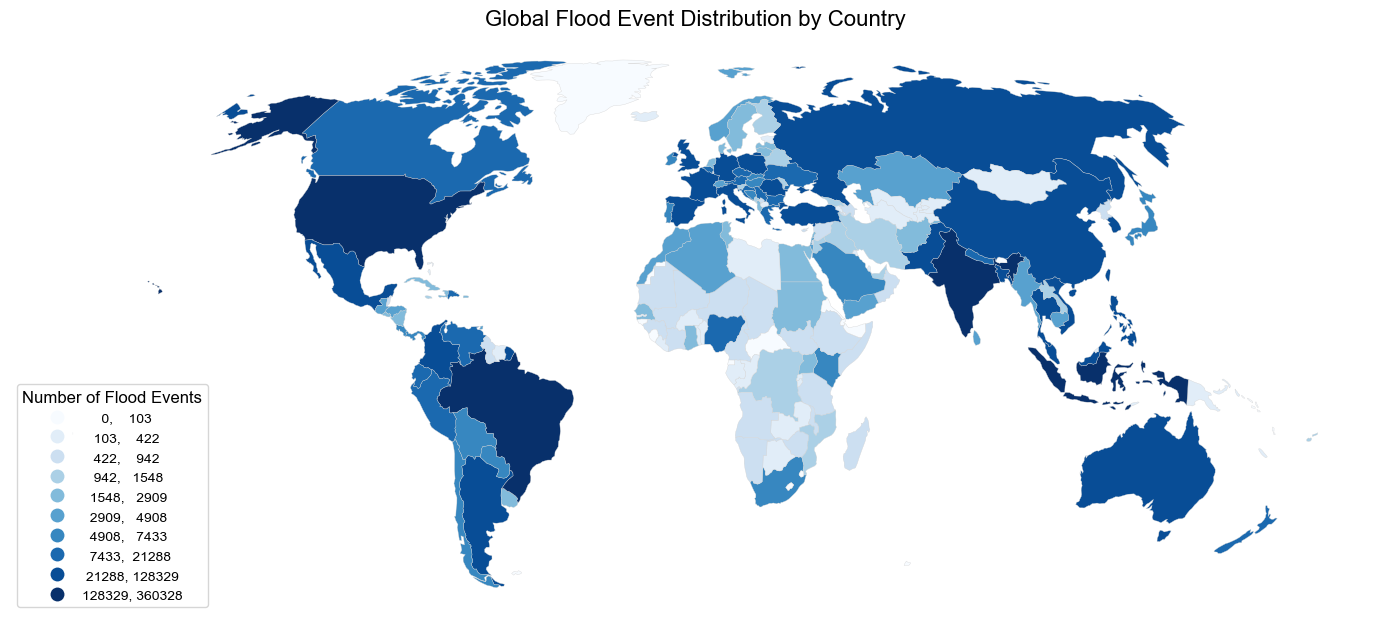

In [19]:
fig, ax = plt.subplots(figsize=(14, 12))
world1.plot(
    ax=ax,
    column='记录数',
    cmap='Blues',
    scheme='jenkscaspall',
    k=10,
    linewidth=0.25,
    edgecolor='lightgray',
    legend=True,
    legend_kwds={
        'loc': 'lower left', 
        'fontsize': 10, 
        'fmt': '{:.0f}',
        'title_fontsize': 12, 
        'title': 'Number of Flood Events'
    }
)
ax.axis('off')
ax.set_title('Global Flood Event Distribution by Country', fontsize=16)
plt.tight_layout()
plt.savefig('global_flood_by_country.png', dpi=1000, bbox_inches='tight')
plt.show()

### 插入子图

In [20]:
result['start_date'] = pd.to_datetime(result['start_date'])

# 月
result['year_month'] = result['start_date'].dt.to_period('M')
monthly = (
    result.groupby(['year_month', 'CONTINENT'])
    .size()
    .reset_index(name='flood_count')
)
monthly['year_month'] = monthly['year_month'].astype(str)

# 年
result['year'] = result['start_date'].dt.year
yearly = (
    result.groupby(['year', 'CONTINENT'])
    .size()
    .reset_index(name='flood_count')
)

In [21]:
monthly['month'] = pd.to_datetime(monthly['year_month']).dt.month
polar_data = (
    monthly.groupby(['month', 'CONTINENT'])['flood_count']
    .sum()
    .reset_index()
)

C:\Users\15499\AppData\Local\Temp\ipykernel_13816\3839727000.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


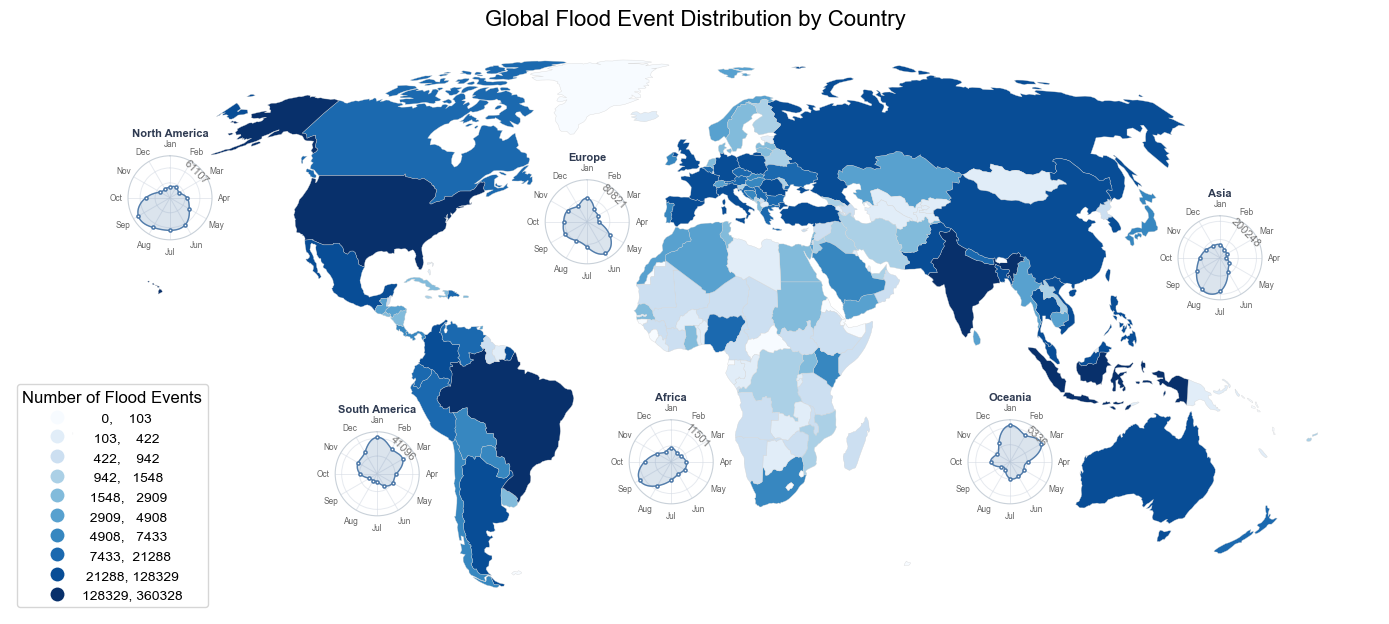

In [22]:
fig, ax = plt.subplots(figsize=(14, 12))

# 地图
world1.plot(
    ax=ax,
    column='记录数',
    cmap='Blues',
    scheme='jenkscaspall',
    k=10,
    linewidth=0.25,
    edgecolor='lightgray',
    legend=True,
    legend_kwds={
        'loc': 'lower left', 
        'fontsize': 10, 
        'fmt': '{:.0f}',
        'title_fontsize': 12, 
        'title': 'Number of Flood Events'
    }
)

# 子图
main_blue = '#4C78A8'
size = 0.07
positions = {
    'North America': [0.09, 0.57],
    'South America': [0.238, 0.34],
    'Europe': [0.388, 0.55],
    'Africa': [0.448, 0.35],
    'Asia': [0.84, 0.52],
    'Oceania': [0.69, 0.35],
}
months = [
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
]
theta = np.linspace(0, 2*np.pi, len(months), endpoint=False)
for continent, pos in positions.items():  # 绘制

    left, bottom = pos
    ax_polar = fig.add_axes(
        [left, bottom, size, size],
        projection='polar'
    )
    ax_polar.set_facecolor('none')
    ax_polar.patch.set_alpha(0)

    sub = polar_data[
        polar_data['CONTINENT'] == continent
    ]
    values = []
    for m in range(1, len(months)+1):

        v = sub[
            sub['month'] == m
        ]['flood_count']

        values.append(
            v.values[0] if len(v) > 0 else 0
        )
    values = np.array(values)

    theta_cycle = np.append(
        theta,
        2*np.pi
    )
    values_cycle = np.append(
        values,
        values[0]
    )
    theta_smooth = np.linspace(
        0,
        2*np.pi,
        400
    )
    spline = make_interp_spline(
        theta_cycle,
        values_cycle,
        k=3,
        bc_type='periodic'
    )
    values_smooth = spline(theta_smooth)
    values_smooth = np.clip(
        values_smooth,
        0,
        None
    )
    ax_polar.fill(
        theta_smooth,
        values_smooth,
        color=main_blue,
        alpha=0.2,
        zorder=2
    )
    ax_polar.plot(
        theta_smooth,
        values_smooth,
        color=main_blue,
        linewidth=1,
        alpha=0.95,
        zorder=3
    )
    ax_polar.scatter(
        theta,
        values,
        facecolor='white',
        edgecolor=main_blue,
        linewidth=1.1,
        s=5,
        zorder=5
    )
    ax_polar.set_xticks(theta)
    ax_polar.set_xticklabels(
        months,
        fontsize=6,
        color='#666666'
    )
    ax_polar.tick_params(
        axis='x',
        pad=-2
    )
    local_max = values.max()
    ax_polar.text(
        np.deg2rad(45),
        local_max * 1,
        f'{local_max:.0f}',
        rotation=-45,
        fontsize=8,
        color='#7A7A7A',
        ha='center',
        va='center'
    )
    ax_polar.set_ylim(
        0,
        local_max * 1.15
    )
    ax_polar.set_theta_zero_location('N')
    ax_polar.set_theta_direction(-1)
    ax_polar.grid(
        color='#D6DCE5',
        linewidth=0.7,
        alpha=0.6
    )
    ax_polar.set_yticklabels([])
    ax_polar.spines['polar'].set_color(
        '#C9D1D9'
    )
    ax_polar.spines['polar'].set_linewidth(0.8)
    ax_polar.set_title(
        continent,
        fontsize=8,
        fontweight='bold',
        pad=14,
        color='#2F3B52'
    )

ax.axis('off')
ax.set_title('Global Flood Event Distribution by Country', fontsize=16)
plt.tight_layout()
plt.savefig('global_flood_by_country.png', dpi=1000, bbox_inches='tight')
plt.show()

In [23]:
polar_data = (
    yearly.groupby(['year', 'CONTINENT'])['flood_count']
    .sum()
    .reset_index()
)

In [24]:
years_full = range(2000, 2027)  # 2000-2026
continents = yearly['CONTINENT'].unique()

pivot_df = yearly.groupby(['year', 'CONTINENT'])['flood_count'].sum().unstack(fill_value=0)
pivot_df = pivot_df.reindex(years_full, fill_value=0)

polar_data = pivot_df.stack().reset_index()
polar_data.columns = ['year', 'CONTINENT', 'flood_count']

C:\Users\15499\AppData\Local\Temp\ipykernel_13816\3246415405.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


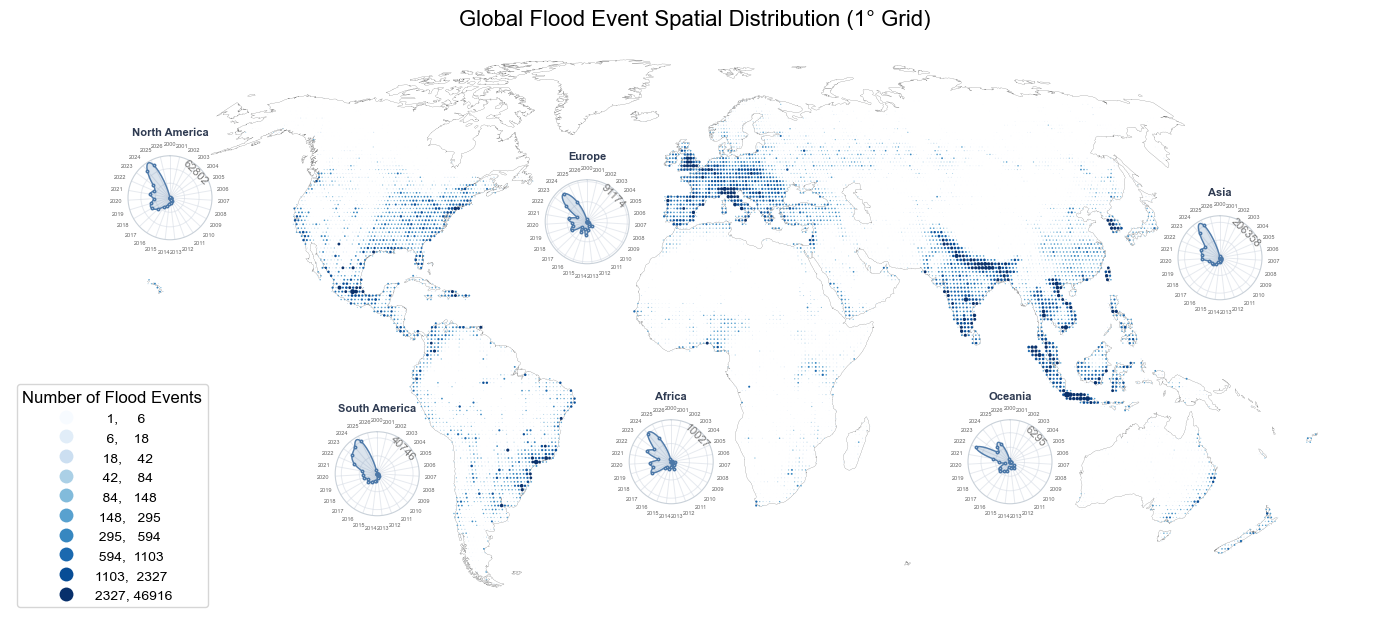

In [ ]:
fig, ax = plt.subplots(figsize=(14, 12))

# 地图
agg_1deg_gdf.plot(
    ax=ax,
    column='记录数',
    cmap='Blues',
    scheme='jenkscaspallsampled',
    k=10,
    legend=True,
    markersize=np.sqrt(agg_1deg_gdf['记录数']) / 12,
    linewidth=0,
    legend_kwds={
        'loc': 'lower left', 
        'fontsize': 10, 
        'fmt': '{:.0f}',
        'title_fontsize': 12, 
        'title': 'Number of Flood Events'
    },
    zorder=2
)
land.boundary.plot(
    ax=ax,
    lw=0.1,
    ec="black",
    zorder=1
)

# 子图
main_blue = '#4C78A8'
size = 0.07
positions = {
    'North America': [0.09, 0.57],
    'South America': [0.238, 0.34],
    'Europe': [0.388, 0.55],
    'Africa': [0.448, 0.35],
    'Asia': [0.84, 0.52],
    'Oceania': [0.69, 0.35],
}
theta = np.linspace(0, 2*np.pi, len(years_full), endpoint=False)
for continent, pos in positions.items():  # 绘制

    left, bottom = pos
    ax_polar = fig.add_axes(
        [left, bottom, size, size],
        projection='polar'
    )
    ax_polar.set_facecolor('none')
    ax_polar.patch.set_alpha(0)

    sub = polar_data[
        polar_data['CONTINENT'] == continent
    ]
    values = []
    for y in years_full:

        v = sub[
            sub['year'] == y
        ]['flood_count']

        values.append(
            v.values[0] if len(v) > 0 else 0
        )
    values = np.array(values)

    theta_cycle = np.append(
        theta,
        2*np.pi
    )
    values_cycle = np.append(
        values,
        values[0]
    )
    theta_smooth = np.linspace(
        0,
        2*np.pi,
        400
    )
    spline = make_interp_spline(
        theta_cycle,
        values_cycle,
        k=3,
        bc_type='periodic'
    )
    values_smooth = spline(theta_smooth)
    values_smooth = np.clip(
        values_smooth,
        0,
        None
    )
    ax_polar.fill(
        theta_smooth,
        values_smooth,
        color=main_blue,
        alpha=0.2,
        zorder=2
    )
    ax_polar.plot(
        theta_smooth,
        values_smooth,
        color=main_blue,
        linewidth=1,
        alpha=0.95,
        zorder=3
    )
    ax_polar.scatter(
        theta,
        values,
        facecolor='white',
        edgecolor=main_blue,
        linewidth=1.1,
        s=3,
        zorder=5
    )
    ax_polar.set_xticks(theta)
    ax_polar.set_xticklabels(
        years_full,
        fontsize=4,
        color='#666666'
    )
    ax_polar.tick_params(
        axis='x',
        pad=-2
    )
    local_max = values.max()
    ax_polar.text(
        np.deg2rad(45),
        local_max * 1,
        f'{local_max:.0f}',
        rotation=-45,
        fontsize=8,
        color='#7A7A7A',
        ha='center',
        va='center'
    )
    ax_polar.set_ylim(
        0,
        local_max * 1.15
    )
    ax_polar.set_theta_zero_location('N')
    ax_polar.set_theta_direction(-1)
    ax_polar.grid(
        color='#D6DCE5',
        linewidth=0.7,
        alpha=0.6
    )
    ax_polar.set_yticklabels([])
    ax_polar.spines['polar'].set_color(
        '#C9D1D9'
    )
    ax_polar.spines['polar'].set_linewidth(0.8)
    ax_polar.set_title(
        continent,
        fontsize=8,
        fontweight='bold',
        pad=15,
        color='#2F3B52'
    )

ax.axis('off')
ax.set_title('Global Flood Event Spatial Distribution (1° Grid)', fontsize=16)

plt.tight_layout()
plt.savefig('global_flood.png', dpi=1000, bbox_inches='tight')
plt.show()